In [ ]:
#Installing kaggle library
#Uploading kaggle.json file (token to connect to kaggle)
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanjaldir","key":"cb91ac02c819a45f54ad9446b7b44eb7"}'}

In [ ]:
#Moving kaggle.json file to correct location
#Setting appropriate permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Downloading dataset
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database -p /content/covid19_radiography

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 99% 774M/778M [00:12<00:00, 110MB/s] 
100% 778M/778M [00:12<00:00, 66.8MB/s]


In [ ]:
#Unzipping dataset
!unzip /content/covid19_radiography/covid19-radiography-database.zip -d /content/covid19_radiography

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: /c

In [ ]:
#Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import gc
import sys
import psutil
import tables
import dask.dataframe as dd
import zarr

In [ ]:
#Setting folder path
folder_path = "/content/covid19_radiography/COVID-19_Radiography_Dataset"

In [ ]:
#Setting subfolder paths
#subfolder_paths = ["COVID/images", 'Lung_Opacity/images', "Normal/images", "Viral Pneumonia/images"]
subfolder_paths = ["Viral Pneumonia/images"]

In [ ]:
#Function to convert to graysscale
def convert_to_greyscale(img):
  grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  return grey_img

In [ ]:
#Function to normalize pixel values
def normalize_pixel(img):
  normalized_img = img / 255.0
  return normalized_img

In [ ]:
#Function to retrieve pixel values
def get_1d_array(img):
  img_flattened = img.flatten()
  return img_flattened

In [ ]:
#Function to track memory
def log_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    #Converting bytes to megabytes
    print(f'Memory usage: {mem_info.rss / (1024 ** 2):.2f} MB')

In [ ]:
#Function to estimate memory usage to eventually estimate batch size
def estimate_memory_usage(img_path):
    #Reading image
    image = cv2.imread(img_path)
    #Converting to grayscale
    grey_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #Normalizing
    norm_img = grey_img / 255.0
    #Retrieving one-d-array
    one_d_array = norm_img.flatten()

    #Determining memory usage for each step
    image_size = sys.getsizeof(image)
    grey_img_size = sys.getsizeof(grey_img)
    norm_img_size = sys.getsizeof(norm_img)
    one_d_array_size = sys.getsizeof(one_d_array)

    return image_size + grey_img_size + norm_img_size + one_d_array_size

In [ ]:
#Function to process a batch of images
#Batching ensures that only a limited number of images are processed and stored in memory at a time
#Only a small subset (the current batch) of processed images is kept in memory at any time
def process_batch(img_paths):

  batch_pixel_values = []
  batch_case_names = []

  for img_path in img_paths:
      #img_string = os.path.splitext(os.path.basename(img_path))[0]
      image = cv2.imread(img_path)
      grey_img = convert_to_greyscale(image)
      norm_img = normalize_pixel(grey_img)
      one_d_array = get_1d_array(norm_img)

      #Appending the 1D array to the list of batch pixel values
      batch_pixel_values.append(one_d_array)
      #batch_case_names.append(img_string.split('-')[0])
      batch_case_names.append(3)

      #Deleting intermediate variables to free memory
      del image, grey_img, norm_img, one_d_array
      #Manually trigger garbage collection
      #The memory used by intermediate variables is reclaimed by the garbage collector
      gc.collect()

  #Converting batch pixel values to a numpy array
  batch_pixel_values = np.array(batch_pixel_values, dtype=np.float32)
  return batch_pixel_values, batch_case_names

In [ ]:
#Checking estimated memory usage for one image
img_path = '/content/covid19_radiography/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png'
memory_per_image = estimate_memory_usage(img_path)
#Converting from bytes to megabytes
memory_per_image = memory_per_image / (1024 ** 2)
print(f"{memory_per_image} MB")

1.7056770324707031 MB


In [ ]:
#Estimating batch size
#Converting GB to MB
free_memory_mb = 11.41 * 1024
#Calculating batch size theoretically
batch_size = free_memory_mb / memory_per_image
print(batch_size)

6849.972050732109


In [ ]:
#Setting batch size
batch_size = 50
index = 0

In [ ]:
#Setting empty lists for pixel values and cases
pixel_values = np.empty((0, 299 * 299), dtype=np.float32)
case_names = []
index = 0
pixel_values.shape

(0, 89401)

In [ ]:
for subfolder in subfolder_paths:
    subfolder_path = os.path.join(folder_path, subfolder)
    image_files = os.listdir(subfolder_path)

    #Processing images in batches
    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i + batch_size]
        batch_paths = [os.path.join(subfolder_path, img) for img in batch_files]
        batch_pixel_values, batch_case_names = process_batch(batch_paths)

        # Extend the main lists with batch data
        pixel_values = np.vstack([pixel_values, batch_pixel_values])
        case_names.extend(batch_case_names)

        #Logging memory usage
        log_memory_usage()
        index +=1
        print(index)

        # Free memory after processing each batch
        del batch_pixel_values, batch_case_names
        gc.collect()

Memory usage: 249.57 MB
1
Memory usage: 282.06 MB
2
Memory usage: 350.32 MB
3
Memory usage: 385.07 MB
4
Memory usage: 418.67 MB
5
Memory usage: 452.73 MB
6
Memory usage: 486.71 MB
7
Memory usage: 520.89 MB
8
Memory usage: 555.02 MB
9
Memory usage: 589.02 MB
10
Memory usage: 623.16 MB
11
Memory usage: 657.39 MB
12
Memory usage: 691.38 MB
13
Memory usage: 725.55 MB
14
Memory usage: 759.69 MB
15
Memory usage: 793.75 MB
16
Memory usage: 827.89 MB
17
Memory usage: 862.05 MB
18
Memory usage: 896.21 MB
19
Memory usage: 930.26 MB
20
Memory usage: 964.32 MB
21
Memory usage: 998.33 MB
22
Memory usage: 1032.61 MB
23
Memory usage: 1066.63 MB
24
Memory usage: 1100.73 MB
25
Memory usage: 1134.85 MB
26
Memory usage: 1162.16 MB
27


In [ ]:
#Checking length of lists
print(len(pixel_values))
print(len(case_names))

1345
1345


In [ ]:
#Checking first 1d array in list
print(len(pixel_values[0]))

89401


In [ ]:
#Checking type and shape
print(type(pixel_values), pixel_values.shape)

<class 'numpy.ndarray'> (1345, 89401)


In [ ]:
#Dropping duplicates
#rounded_pixel_values = np.round(pixel_values, decimals=6)
_, unique_indices = np.unique(rounded_pixel_values, axis=0, return_index=True)
pixel_values = pixel_values[sorted(unique_indices)]
case_names = [case_names[i] for i in sorted(unique_indices)]

In [ ]:
#Checking size
print(pixel_values.shape)
print(len(case_names))

(1338, 89401)
1338


In [ ]:
#Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Saving array in drive
output_folder = "/content/drive/My Drive/Team Project X-Rays/Dataframes/"
np.save(os.path.join(output_folder, "data_viral.npy"), pixel_values)
np.save(os.path.join(output_folder, "target_viral.npy"), case_names)

In [ ]:
#Loading array
array = np.load("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_viral.npy")

In [ ]:
#Memmap array: Working with large datasets that do not fit into RAM.
memmap_array = np.memmap("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_viral.dat", dtype=array.dtype, mode='w+', shape=array.shape)

#Copying data from the loaded array to the memmap array
memmap_array[:] = array[:]

#Flushing changes to disk
memmap_array.flush()

In [ ]:
#Loading arrays
memmap_covid = np.memmap("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_covid.dat", dtype=np.float32, mode='r', shape = (3565, 89401))
memmap_normal = np.memmap("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_normal.dat", dtype=np.float32, mode='r', shape = (10192, 89401))
memmap_lung = np.memmap("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_lung.dat", dtype=np.float32, mode='r', shape = (6012, 89401))
memmap_viral = np.memmap("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_viral.dat", dtype=np.float32, mode='r', shape = (1338, 89401))
memmap_covid.size/299/299

3565.0

In [ ]:
#Checking shapes
print(memmap_covid.shape)
print(memmap_normal.shape)
print(memmap_lung.shape)
print(memmap_viral.shape)

(3565, 89401)
(10192, 89401)
(6012, 89401)
(1338, 89401)


In [ ]:
#Concatenating arrays
combined_array = np.concatenate((memmap_covid, memmap_normal, memmap_lung, memmap_viral), axis=0)

#Saving the concatenated array as a Zarr file
zarr_path = "/content/drive/My Drive/Team Project X-Rays/Dataframes/data_1.1.zarr"
zarr.save(zarr_path, combined_array)

In [ ]:
#Loading target arrays
covid = np.load("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_covid.npy")
normal = np.load("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_normal.npy")
lung = np.load("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_lung.npy")
viral = np.load("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_viral.npy")

In [ ]:
#Combining array
combined_array = np.concatenate((covid, normal, lung, viral), axis=0)

In [ ]:
#Checking shape
combined_array.shape

(21107,)

In [ ]:
#Checking content
np.unique(combined_array)

array([0, 1, 2, 3])

In [ ]:
total = combined_array.size

#Calculating the counts of each unique value
unique, counts = np.unique(combined_array, return_counts=True)

#Calculating the proportion of each unique value
proportion = counts / total

#Displaying
for value, prop in zip(unique, proportion):
    print(f"Proportion of case {value}: {prop:.4f}")

Proportion of case 0: 0.1689
Proportion of case 1: 0.4829
Proportion of case 2: 0.2848
Proportion of case 3: 0.0634


In [ ]:
#Saving target array
zarr_path = "/content/drive/My Drive/Team Project X-Rays/Dataframes/target_1.1.zarr"
zarr.save(zarr_path, combined_array)

In [ ]:
#Loading zarr array
zarr_array = zarr.open("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_1.1.zarr", mode='r')

In [ ]:
#Checking shape
zarr_array.shape

(21107, 89401)

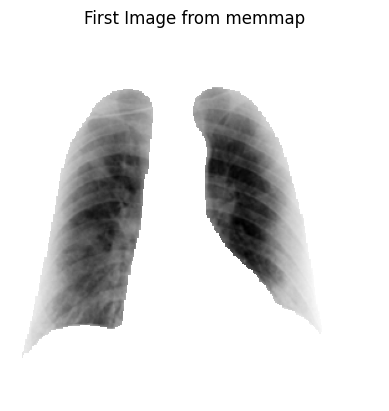

In [ ]:
image_1d = zarr_array[5]
image_2d = image_1d.reshape((299, 299))

plt.imshow(image_2d, cmap='gray')
plt.title('First Image from zarr')
plt.axis('off')
plt.show()